In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [44]:
# Load dataset
df = pd.read_csv("creditcard.csv")
print(df.head)

<bound method NDFrame.head of         Time        V1        V2        V3        V4        V5        V6  \
0          0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388   
1          0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361   
2          1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499   
3          1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203   
4          2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921   
...      ...       ...       ...       ...       ...       ...       ...   
55546  47004  1.283418  0.354874  0.158519  0.607335 -0.186818 -0.865444   
55547  47005 -0.969584 -0.514812  1.010076 -0.492493 -1.074442  0.812377   
55548  47005 -0.448083  0.936043  1.308078  0.424255  0.141240 -0.224215   
55549  47005  0.616391 -0.770376 -0.306186  1.374006 -0.177289  0.186992   
55550  47005 -2.212795  0.701029  1.063799  1.449808 -1.045775  0.416184   

             V7        V8        V9  ...       V21       

In [45]:
print("Shape of dataset:")
print(df.shape)

Shape of dataset:
(55551, 31)


In [46]:
# Check null values
print("Null values before cleaning:")
print(df.isnull().sum())

# Drop null values
df = df.dropna()

Null values before cleaning:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [47]:
# Check again
print("\nNull values after cleaning:")
print(df.isnull().sum())


Null values after cleaning:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [48]:
print("\nClass Distribution:")
print(df["Class"].value_counts())

print("\nClass Distribution (%):")
print(df["Class"].value_counts(normalize=True) * 100)


Class Distribution:
Class
0.0    55394
1.0      156
Name: count, dtype: int64

Class Distribution (%):
Class
0.0    99.719172
1.0     0.280828
Name: proportion, dtype: float64


In [49]:
# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]
print("\nFeature Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)


Feature Shape:
(55550, 30)

Target Shape:
(55550,)


In [50]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [51]:
# Scale data for SVM
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
# Apply SMOTE only to training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0.0    44315
1.0      125
Name: count, dtype: int64

After SMOTE:
Class
0.0    44315
1.0    44315
Name: count, dtype: int64


In [54]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train_smote, y_train_smote)

# Fraud probability
y_prob = model.predict_proba(X_test_scaled)[:, 1]
print("\nFirst 10 probabilities:")
print(y_prob[:10])

print("\nProbability Information:")

print(
    "Minimum probability:",
    y_prob.min()
)

print(
    "Maximum probability:",
    y_prob.max()
)

print(
    "Mean probability:",
    y_prob.mean()
)


# Threshold tuning
threshold = 0.30

y_pred = (y_prob >= threshold).astype(int)

print("\nXGBoost Results")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))


First 10 probabilities:
[4.8532002e-04 1.0915898e-03 6.7279220e-04 8.9916539e-05 3.0380962e-04
 3.8939761e-04 1.4661235e-04 2.5751514e-04 1.4887498e-02 1.5261969e-04]

Probability Information:
Minimum probability: 1.7534452e-05
Maximum probability: 0.9996793
Mean probability: 0.007373561

XGBoost Results
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     11079
         1.0       0.46      0.97      0.62        31

    accuracy                           1.00     11110
   macro avg       0.73      0.98      0.81     11110
weighted avg       1.00      1.00      1.00     11110

Confusion Matrix:
[[11044    35]
 [    1    30]]
ROC-AUC: 0.9990391586523764


In [55]:
for threshold in [0.1, 0.2, 0.3, 0.4, 0.5]:

    pred = (y_prob >= threshold).astype(int)

    print(
        threshold,
        "Precision:", precision_score(y_test, pred),
        "Recall:", recall_score(y_test, pred),
        "F1:", f1_score(y_test, pred)
    )

0.1 Precision: 0.2727272727272727 Recall: 0.967741935483871 F1: 0.425531914893617
0.2 Precision: 0.38461538461538464 Recall: 0.967741935483871 F1: 0.5504587155963303
0.3 Precision: 0.46153846153846156 Recall: 0.967741935483871 F1: 0.625
0.4 Precision: 0.5357142857142857 Recall: 0.967741935483871 F1: 0.6896551724137931
0.5 Precision: 0.6521739130434783 Recall: 0.967741935483871 F1: 0.7792207792207793


In [56]:
svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm.fit(X_train_smote, y_train_smote)

svm_prob = svm.predict_proba(X_test_scaled)[:, 1]

svm_pred = (svm_prob >= 0.5).astype(int)

print("\nSVM Results")
print(classification_report(y_test, svm_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

print("ROC-AUC:", roc_auc_score(y_test, svm_prob))


SVM Results
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     11079
         1.0       0.15      1.00      0.26        31

    accuracy                           0.98     11110
   macro avg       0.57      0.99      0.63     11110
weighted avg       1.00      0.98      0.99     11110

Confusion Matrix:
[[10901   178]
 [    0    31]]
ROC-AUC: 0.9994147602700838



Top Features:
V14       0.520049
V5        0.091138
V4        0.045027
Amount    0.026139
V28       0.025032
V12       0.025019
V18       0.024848
V26       0.021376
V8        0.020680
V7        0.020480
dtype: float32


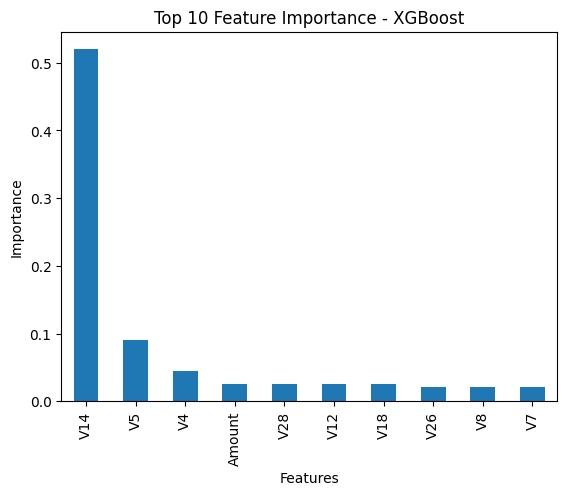

In [57]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop Features:")
print(importance.head(10))

importance.head(10).plot(kind="bar")

plt.title("Top 10 Feature Importance - XGBoost")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()